# 1.4 Connexin Plaque Size Check — Rolling-Ball Radius Calibration

In [27]:
from pathlib import Path

import stackview

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops_table
from skimage.morphology import white_tophat, disk
from skimage.restoration import rolling_ball

BASE_DIR = Path.cwd().parent
PIXEL_SIZE_UM = 0.325  # lateral (y, x) pixel size — matches src/localization.py and src/nuclei_assignment.py


## 0. Load zone samples

In [2]:
zone_samples_path = BASE_DIR / 'data' / 'cropped_sample_regions.csv'
zone_samples = pd.read_csv(zone_samples_path)
print(f"Loaded {len(zone_samples)} zones from {zone_samples_path}")
zone_samples


Loaded 8 zones from /home/rck292/Project/data/cropped_sample_regions.csv


,zone_number,zone_label,z_start,z_end,sample_plane,sample_plane_intensity
0,2,rising-1,0,41,7,515.66
1,3,rising-2,41,109,75,2222.98
2,4,rising-3,109,176,142,5335.92
3,5,rising-4,176,244,210,9162.24
4,6,rising-5,244,312,278,11514.37
5,7,falling-1,312,357,334,11384.69
6,8,falling-2,357,403,380,9689.39
7,9,falling-3,403,441,426,7286.28


## 1. Load the preprocessed image stack

In [8]:
# 1_4, cell 5
cnx_path = BASE_DIR / 'data' / 'raw' / 'corrected_images' / 'cnx43.tif'
cnx_img = io.imread(cnx_path)
print(f"Loaded stack: shape={cnx_img.shape}, dtype={cnx_img.dtype}")

# remove black border on top (matches convention in 1_1_preprocessing.ipynb)
cnx_img = cnx_img[60:501, :, 23:999]  
print(f"After border crop: shape={cnx_img.shape}")

n_planes = cnx_img.shape[0]
out_of_range = zone_samples[~zone_samples['sample_plane'].between(0, n_planes - 1)]
if len(out_of_range):
    print("WARNING: sample planes out of range for this stack:")
    print(out_of_range)
else:
    print("All zone_samples.sample_plane values are within the stack range.")


Loaded stack: shape=(510, 2048, 1012), dtype=uint16
After border crop: shape=(441, 2048, 976)
All zone_samples.sample_plane values are within the stack range.


## 2. Radius sensitivity sweep

Background removal applied at several candidate radii, side-by-side, per zone — compare
against the measured plaque sizes above to judge whether radius=10 is a good fit everywhere,
or whether the outer zones need a different value.

In [56]:
def plot_radius_sweep(plane, radii, title, vmax_percentile=99.5):
    fig, axes = plt.subplots(1, len(radii) + 1, figsize=(4 * (len(radii) + 1), 4))
    vmax_raw = np.percentile(plane, vmax_percentile)
    axes[0].imshow(plane, cmap='gray', vmax=vmax_raw)
    axes[0].set_title('raw')
    axes[0].axis('off')
    for ax, r in zip(axes[1:], radii):
        background = rolling_ball(plane.astype(np.float32), radius=r)
        corrected = np.clip(plane.astype(np.float32) - background, 0, None)
        vmax = np.percentile(corrected, vmax_percentile)
        ax.imshow(corrected, cmap='gray', vmax=vmax)
        ax.set_title(f'radius={r}')
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


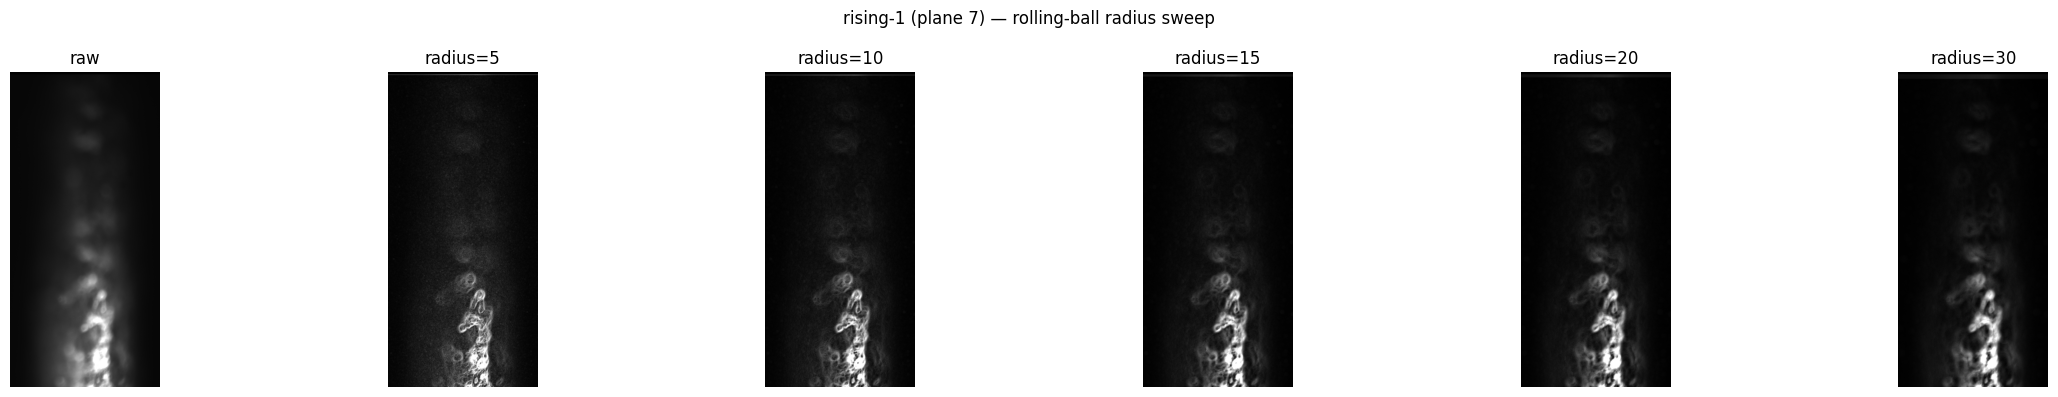

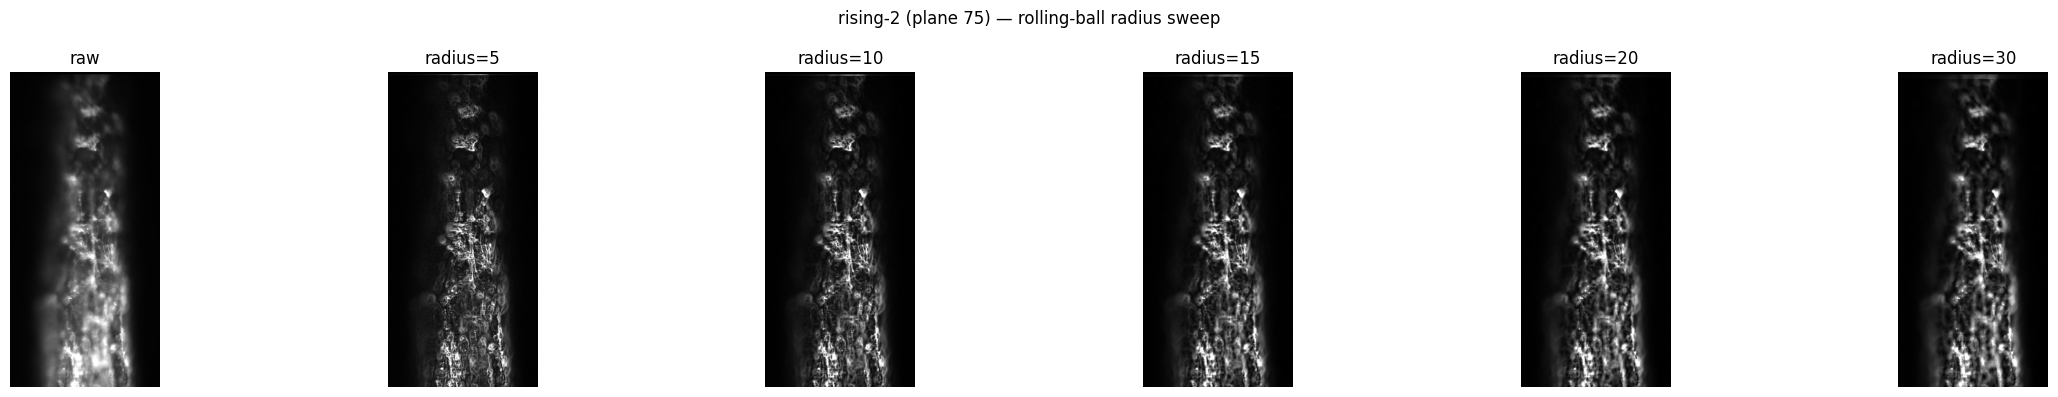

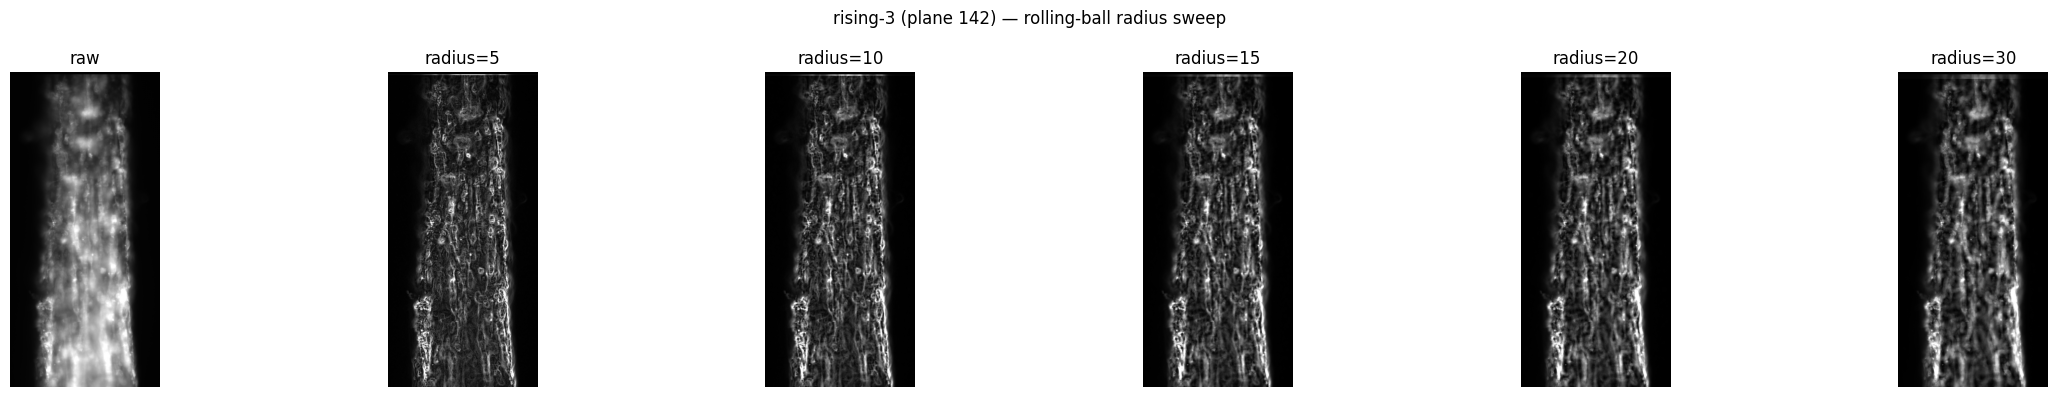

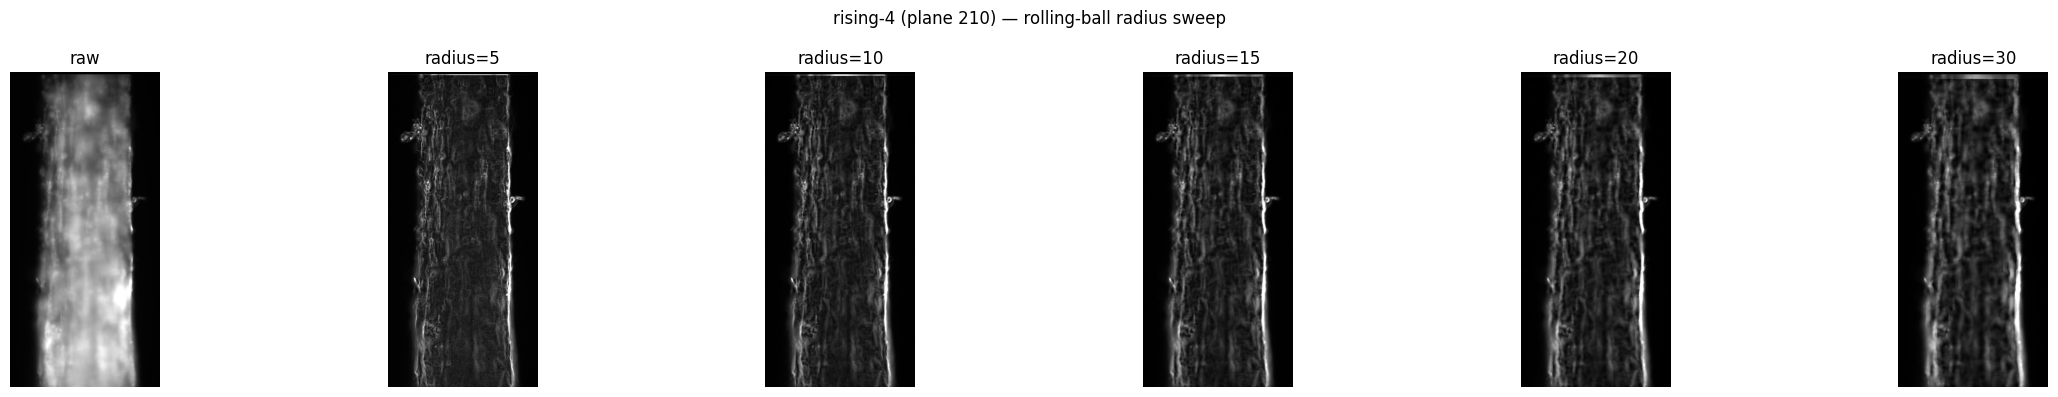

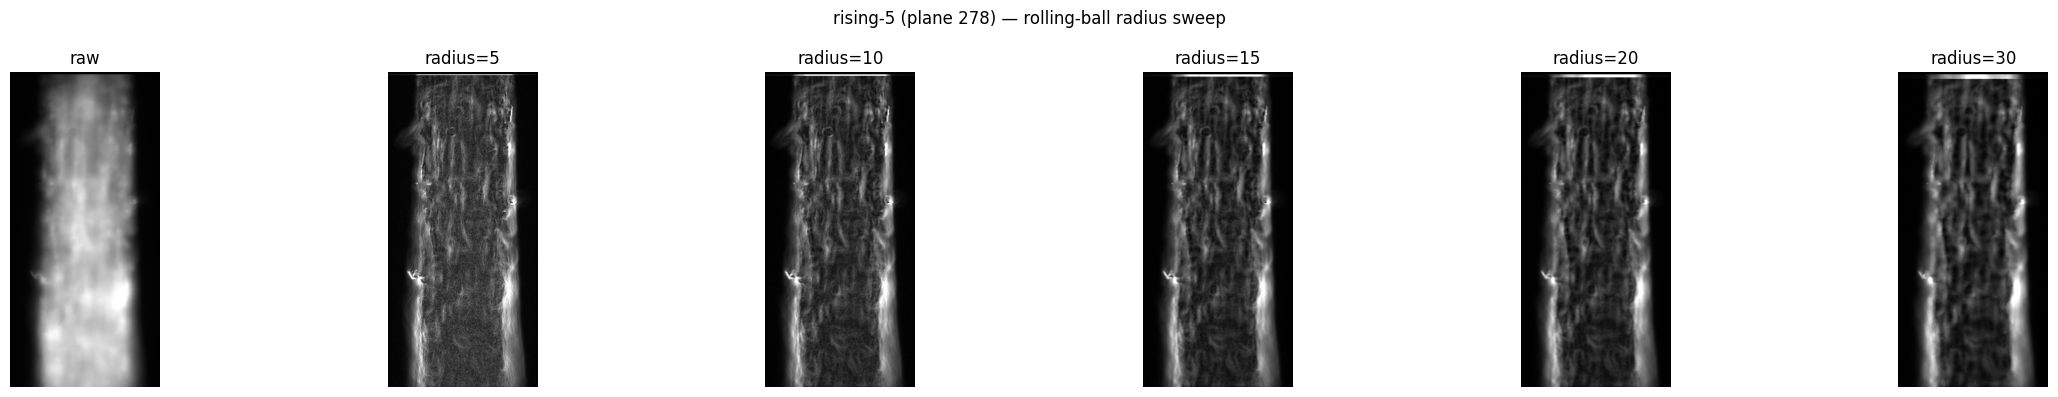

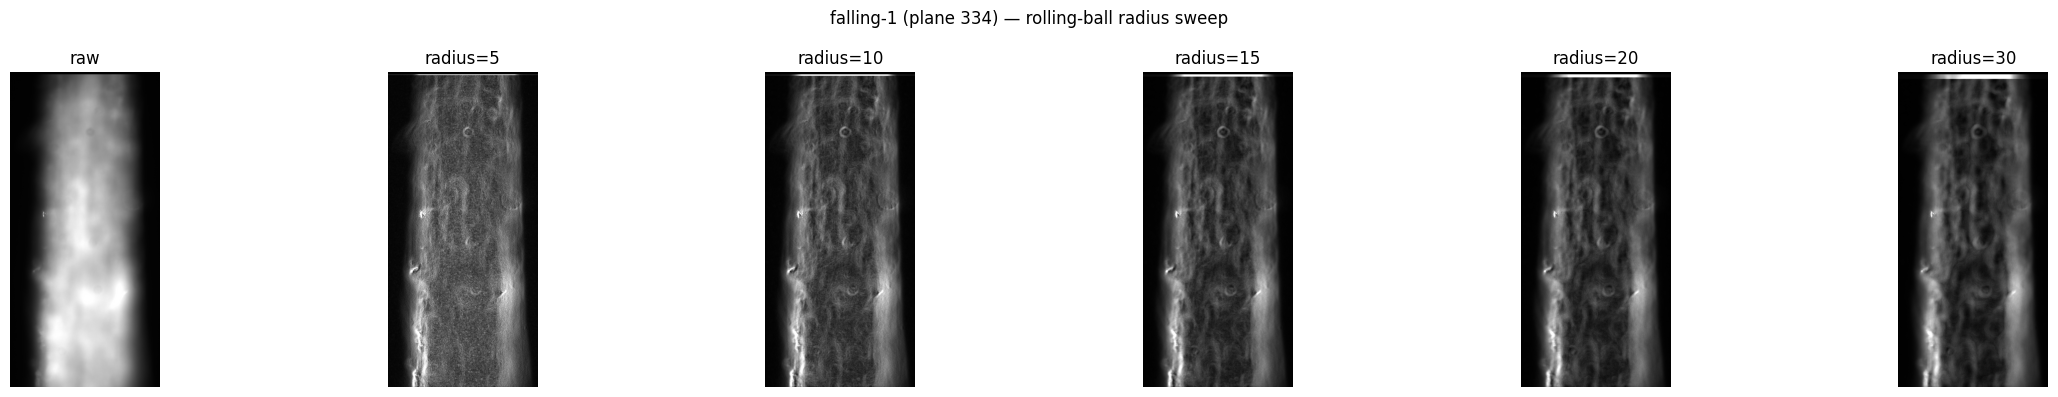

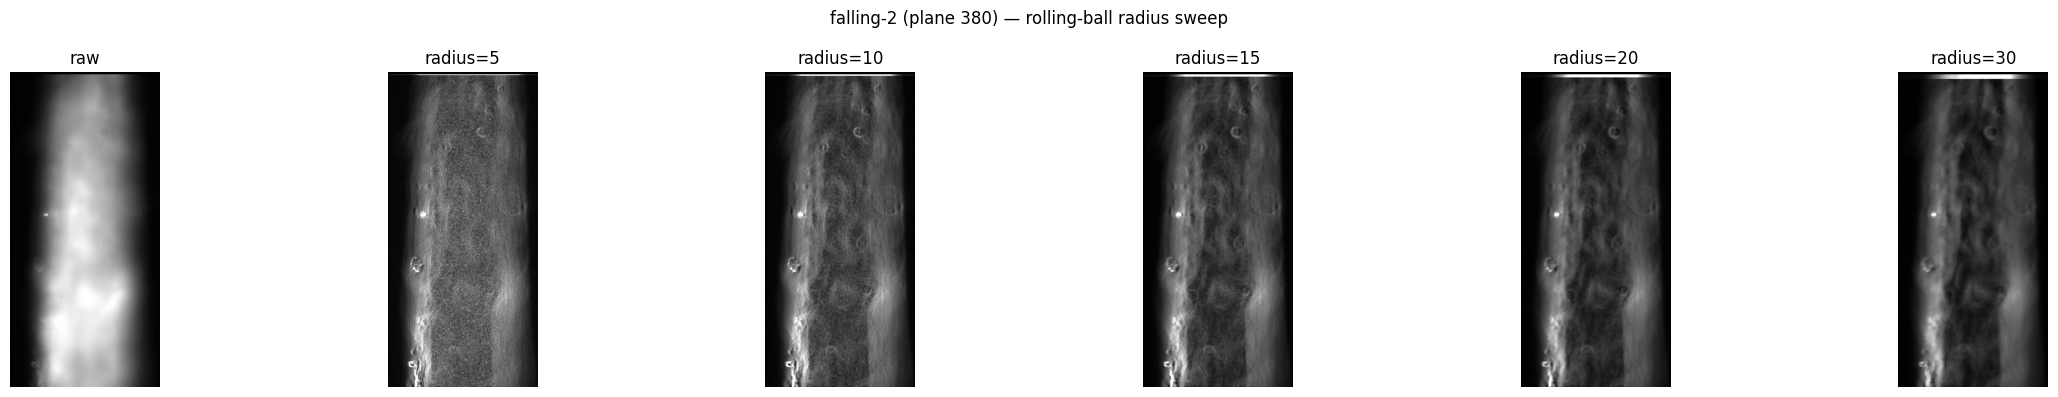

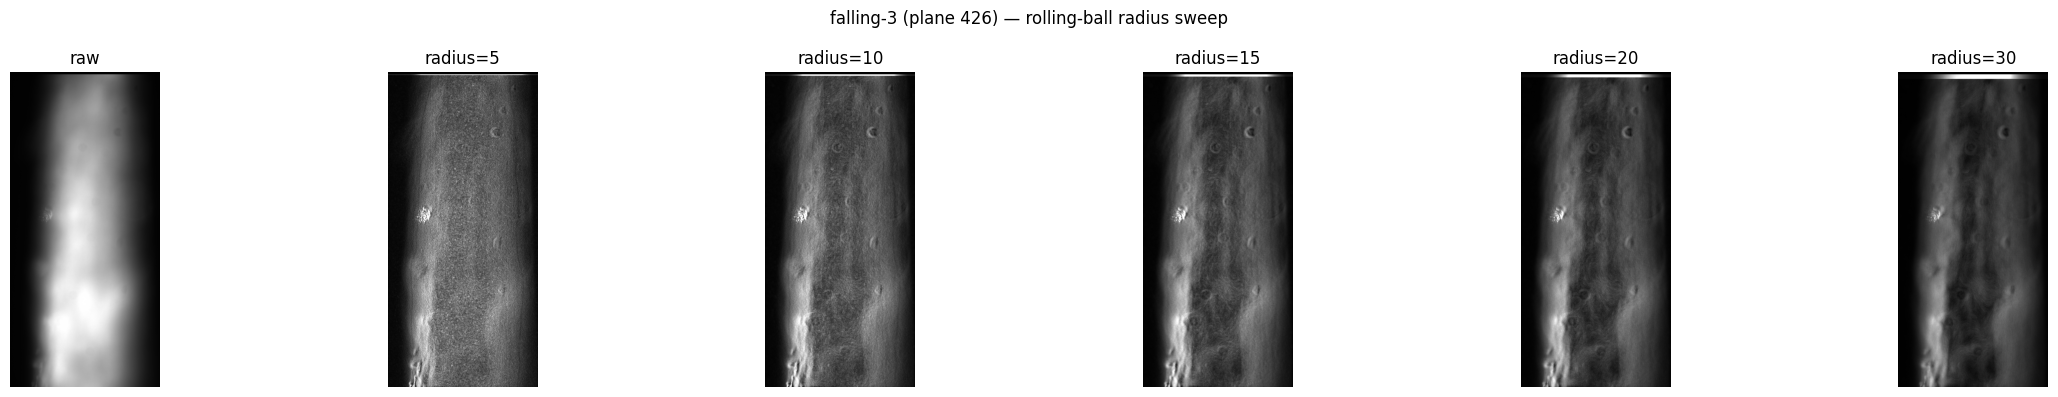

In [57]:
radii_to_compare = [5, 10, 15, 20, 30]

for _, row in zone_samples.iterrows():
    plane = cnx_img[int(row['sample_plane'])]
    plot_radius_sweep(
        plane,
        radii_to_compare,
        title=f"{row['zone_label']} (plane {int(row['sample_plane'])}) — rolling-ball radius sweep",
    )


## 3. Manual measurement — pixel grid + scale bar

Full-resolution view per zone with a pixel grid, so plaque diameters can be read directly by
counting grid squares (labelled in both px and µm).

In [80]:
import numpy as np
import matplotlib.pyplot as plt

def plot_large_region(
    plane,
    x_range=(250, 700),
    y_range=(750, 1500),
    pixel_size_um=PIXEL_SIZE_UM,
    scalebar_um=50,
    vmax_percentile=99.5,
    grid_spacing_px=5,
    figsize=(8, 12)
):

    x0, x1 = x_range
    y0, y1 = y_range

    # Extract region
    roi = plane[y0:y1, x0:x1]

    vmax = np.percentile(roi, vmax_percentile)

    fig, ax = plt.subplots(figsize=figsize)

    ax.imshow(
        roi,
        cmap="gray",
        vmax=vmax
    )

    # Pixel grid every 5 px
    ax.set_xticks(np.arange(0, roi.shape[1], grid_spacing_px))
    ax.set_yticks(np.arange(0, roi.shape[0], grid_spacing_px))

    ax.grid(
        True,
        color="cyan",
        linewidth=0.3,
        alpha=0.4
    )

    ax.tick_params(
        labelsize=8,
        length=3
    )

    # Scale bar
    scalebar_px = scalebar_um / pixel_size_um

    ax.plot(
        [roi.shape[1]-scalebar_px-20,
         roi.shape[1]-20],
        [roi.shape[0]-20,
         roi.shape[0]-20],
        color="white",
        linewidth=4
    )

    ax.text(
        roi.shape[1]-scalebar_px/2-20,
        roi.shape[0]-35,
        f"{scalebar_um} µm",
        color="white",
        ha="center",
        fontsize=10
    )

    ax.set_title(
        f"Region x={x0}:{x1}, y={y0}:{y1}"
    )

    plt.tight_layout()
    plt.show()

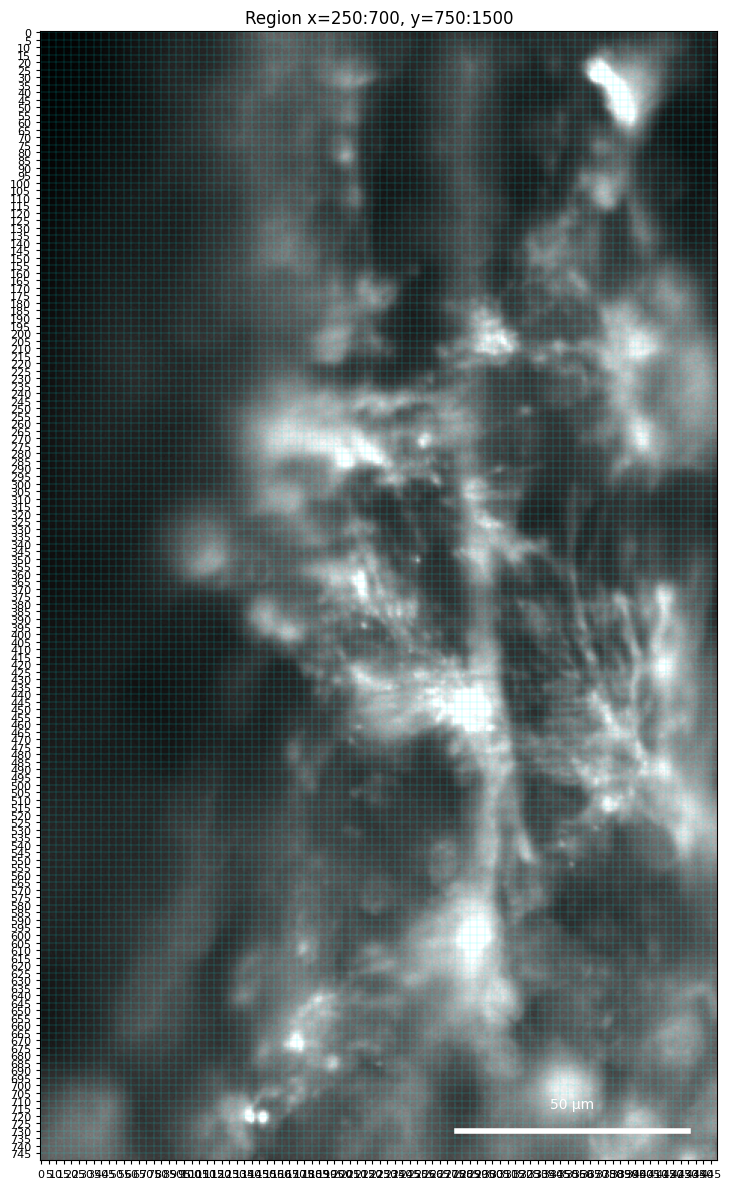

In [81]:
plot_large_region(
    plane,
    x_range=(250,700),
    y_range=(750,1500),
    scalebar_um=50
)